# Lung Cancer Survival Prediction using a Decision Tree

This notebook builds a Decision Tree classifier that predicts whether a lung cancer patient survived (1) or did not survive (0), using patient information such as age, gender, cancer stage, BMI, cholesterol level, smoking status and treatment type. Because the target has two possible classes, this is a supervised binary classification problem. A Decision Tree works like a flowchart: it asks questions about the input features and follows different branches until it reaches a final prediction.

## 1. Loading the Dataset

The dataset file is uploaded and read into a Pandas DataFrame. It contains 886,105 records and 22 columns. The data is already preprocessed: numeric columns are scaled and the smoking status and treatment columns are one-hot encoded, so it can be given directly to the model.

In [1]:
import pandas as pd
try:
    from google.colab import files
    uploaded = files.upload()
    csv_name = list(uploaded.keys())[0]
except ImportError:
    csv_name = "lung_cancer_processed.csv"   # when running outside Colab

df = pd.read_csv(csv_name)
print(df.shape)
df.head()

Saving lung_cancer_processed.zip to lung_cancer_processed.zip
(886105, 22)


,age,gender,country,cancer_stage,family_history,bmi,cholesterol_level,hypertension,asthma,cirrhosis,...,treatment_duration_days,diagnosis_year,smoking_Current Smoker,smoking_Former Smoker,smoking_Never Smoked,smoking_Passive Smoker,treatment_Chemotherapy,treatment_Combined,treatment_Radiation,treatment_Surgery
0,0.918122,0,26,1,1,-0.130726,-0.797375,0,0,1,...,0.466017,2016,0,0,0,1,1,0,0,0
1,-0.511199,1,19,3,1,1.279336,1.067513,1,1,0,...,-0.244589,2023,0,0,0,1,0,0,0,1
2,1.020216,1,12,3,1,1.613927,0.791233,1,1,0,...,-0.632192,2023,0,1,0,0,0,1,0,0
3,-0.409104,1,1,1,0,1.494430,0.169604,1,1,0,...,-0.108210,2016,0,0,0,1,1,0,0,0
4,-1.838425,0,17,1,0,-1.289845,-1.280865,0,0,0,...,-0.373790,2023,0,0,0,1,0,1,0,0


## 2. Exploring the Target Variable

This step checks the dataset for missing values and counts how many records belong to each class of the target variable `survived`. There are no missing values. About 78% of the records belong to class 0 (not survived) and about 22% to class 1 (survived), which means the dataset is imbalanced. This is important when interpreting the evaluation results later.

In [2]:
print(df.isna().sum().sum(), "missing values")
print(df["survived"].value_counts())
print(df["survived"].value_counts(normalize=True).round(4))

0 missing values
survived
0    690979
1    195126
Name: count, dtype: int64
survived
0    0.7798
1    0.2202
Name: proportion, dtype: float64


## 3. Separating Features and Target, and Splitting the Data

The `survived` column is separated as the target variable (`y`), and the remaining 21 columns form the input features (`X`). The data is then divided into 80% training data and 20% testing data. The training data is used to teach the model, while the testing data is kept aside to evaluate the model on records it has never seen. The `stratify` option keeps the same class proportions in both sets, and `random_state=42` makes the split repeatable.

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop("survived", axis=1)
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(708884, 21) (177221, 21)


## 4. Training the Decision Tree Classifier

A `DecisionTreeClassifier` is created and trained on the training data using the `fit` method. During training, the tree repeatedly chooses the feature and threshold that best separates the two classes at each node, using Gini impurity as the measure of how mixed a group is. After training, the `predict` method is used on the test features to generate predicted classes.

In [4]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## 5. Evaluating the Model

The predictions are compared with the actual test labels using accuracy, precision, recall, F1-score and a confusion matrix. Accuracy is the overall percentage of correct predictions. Precision shows how many of the predicted survivors were actually survivors, and recall shows how many of the actual survivors the model identified. The F1-score balances precision and recall. The confusion matrix shows the number of correct and incorrect predictions for each class. In this run, the model reached an accuracy of 64.12%, with a precision of 22%, a recall of 25% and an F1-score of 24% for the survival class, so it has difficulty identifying survivors.

Accuracy: 64.12 %
              precision    recall  f1-score   support

           0       0.78      0.75      0.77    138196
           1       0.22      0.25      0.24     39025

    accuracy                           0.64    177221
   macro avg       0.50      0.50      0.50    177221
weighted avg       0.66      0.64      0.65    177221

[[103803  34393]
 [ 29196   9829]]


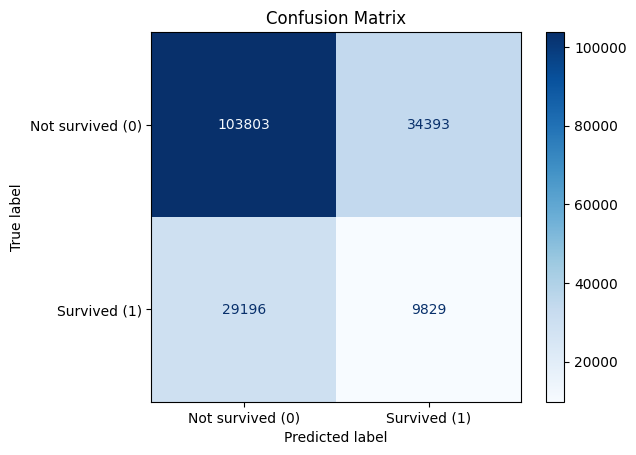

In [5]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)
ConfusionMatrixDisplay(cm, display_labels=["Not survived (0)", "Survived (1)"]).plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

## 6. Comparison with the Majority-Class Baseline

Since about 78% of the records are class 0, a simple model that always predicts "not survived" is created for comparison. This baseline achieves an accuracy of 77.98%, which is higher than the Decision Tree's 64.12%. This shows that accuracy alone is not enough to judge a model on an imbalanced dataset, and that the current tree does not outperform the simple baseline.

In [6]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print("Always predict 'not survived':", round(accuracy_score(y_test, dummy.predict(X_test)) * 100, 2), "%")
print("Decision Tree               :", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

Always predict 'not survived': 77.98 %
Decision Tree               : 64.12 %


## 7. Checking for Overfitting at Different Depths

Decision Trees tend to overfit, meaning they learn the training data too closely and perform worse on new data. To check this, trees with different maximum depths are trained, and their training accuracy, test accuracy and ROC AUC are compared. The unrestricted tree reaches almost 100% accuracy on the training data but only about 64% on the test data, which indicates overfitting. Limiting the depth reduces the overfitting, but the ROC AUC stays close to 0.5, which is equivalent to random guessing.

In [7]:
from sklearn.metrics import roc_auc_score

rows = []
for depth in [3, 5, 8, 12, None]:
    m = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_train, y_train)
    rows.append({
        "max_depth": depth,
        "train_acc": round(m.score(X_train, y_train), 4),
        "test_acc": round(m.score(X_test, y_test), 4),
        "test_auc": round(roc_auc_score(y_test, m.predict_proba(X_test)[:, 1]), 4),
    })
pd.DataFrame(rows)

,max_depth,train_acc,test_acc,test_auc
0,3.0,0.7798,0.7798,0.5005
1,5.0,0.7798,0.7798,0.4983
2,8.0,0.7799,0.7797,0.5007
3,12.0,0.7820,0.7775,0.4996
4,NaN,1.0000,0.6412,0.5015


## 8. Feature Importance

The tree records how much each feature contributed to reducing impurity across its splits. The top ten features are displayed in a table and a bar chart. Features such as treatment duration, BMI and cholesterol level are used most often by the tree. Since the overall performance is weak, this shows which features the model split on rather than proven causes of survival. The timing of `treatment_duration_days` should also be checked, because it may not be available when an early prediction would be made (possible data leakage).

treatment_duration_days    0.1712
bmi                        0.1665
cholesterol_level          0.1464
country                    0.1108
age                        0.1080
diagnosis_year             0.0823
cancer_stage               0.0263
gender                     0.0202
family_history             0.0200
asthma                     0.0198
dtype: float64


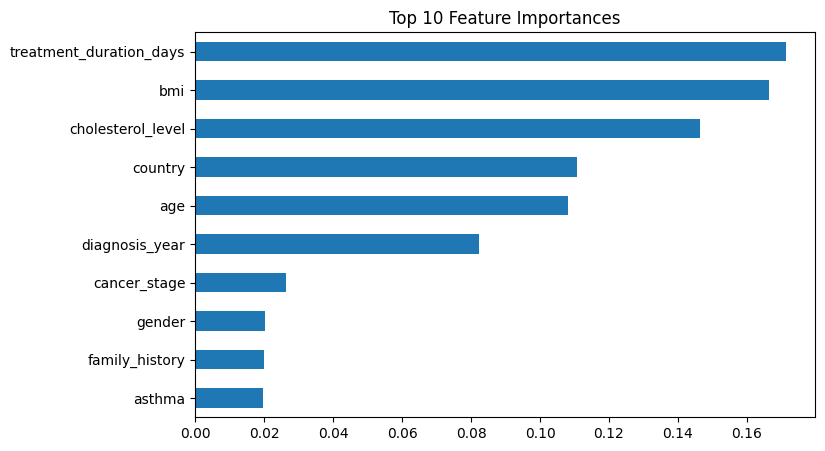

In [8]:
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(imp.head(10).round(4))
imp.head(10).sort_values().plot(kind="barh", figsize=(8, 5), title="Top 10 Feature Importances")
plt.show()

## 9. Visualizing the Tree

A smaller tree limited to a depth of three is plotted so that its structure can be read. Each box shows the splitting condition, the Gini impurity, the number of samples reaching the node, the count of each class, and the majority class. The left branch is followed when the condition is true and the right branch when it is false.

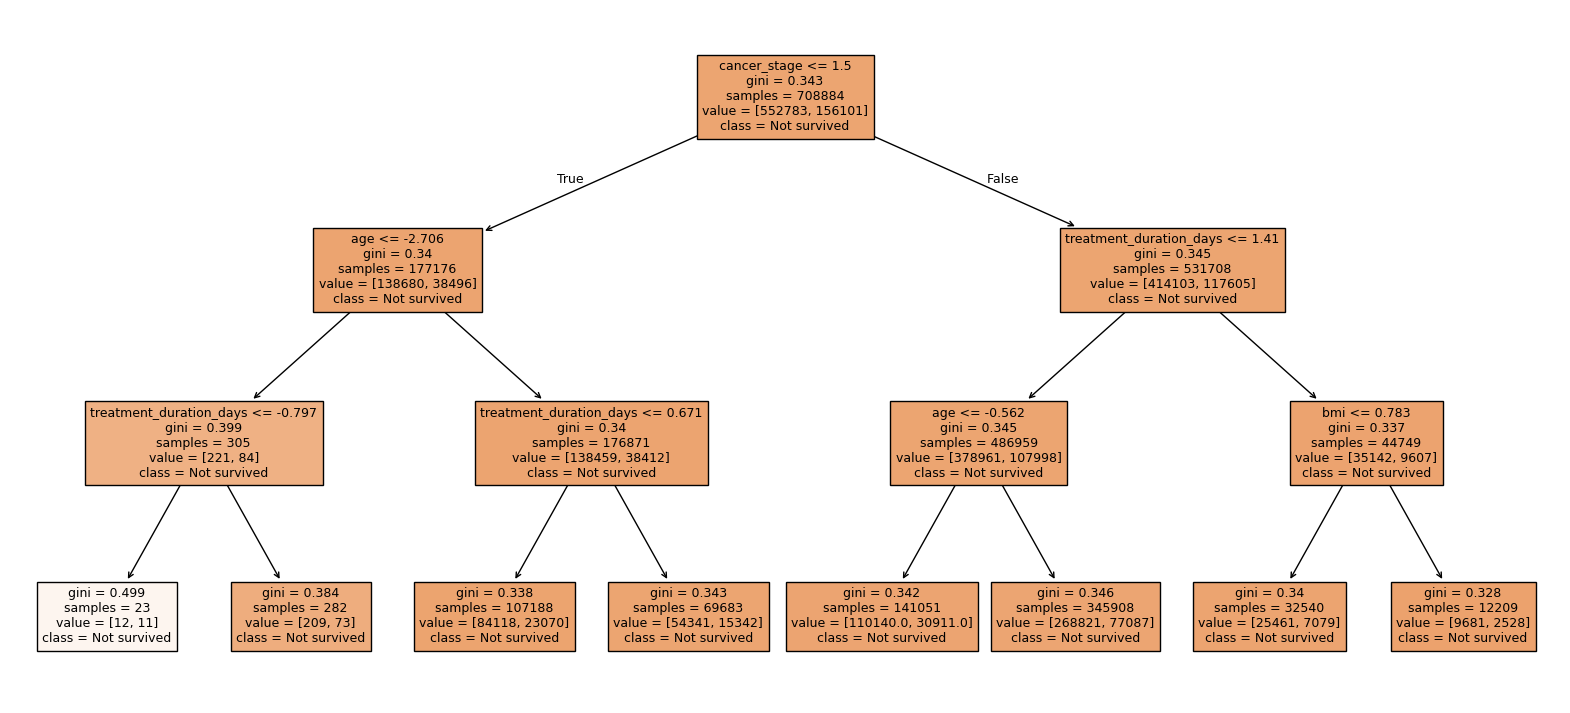

In [9]:
from sklearn.tree import plot_tree

small = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)
plt.figure(figsize=(20, 9))
plot_tree(small, feature_names=X.columns, class_names=["Not survived", "Survived"], filled=True, fontsize=9)
plt.show()

## Conclusion

The Decision Tree is simple, easy to understand and easy to visualize, and it does not require feature scaling. However, on this dataset it does not beat the majority-class baseline and performs poorly on the survival class. Possible improvements include pruning, tuning the maximum depth, handling the class imbalance, cross-validation, feature selection and comparing other algorithms. This is an educational project and the model should not be used for real medical decisions.